# CM3005: Coursework 1 submission

## Project Snapshot
 
**Primary model:** Linear Regression  
**Validation:** Five-fold cross-validation  
**Feature engineering:** Manually engineered features and second-degree polynomial features  
**Additional comparison models:** Random Forest Regressor and Support Vector Regression  
**Target variable:** `ADM_RATE`  
**Scope:** Four-year U.S. institutions with reported admission rates  
**Dataset:** College Scorecard institution-level CSV file from the U.S. Department of Education website (https://collegescorecard.ed.gov/data/)

# Q1. Domain-specific area and objectives of the project

The domain-specific area of this project is predicting how selective different U.S. colleges are. Students and parents commonly compare institutions using admission rate. The College Scorecard provides public institution-level data containing many variables, allowing the problem to be investigated with statistical analysis and machine learning.

The main objective is to develop a **linear regression model** that estimates the reported undergraduate admission rate (`ADM_RATE`) of four-year U.S. institutions from selected institutional characteristics. ADM_RATE was selected as the target variable because it is a widely used numerical indicator of institutional selectivity and is available for many four-year institutions in the College Scorecard dataset. It is also suitable for regression because it is measured as a continuous proportion between 0 and 1. 

Exploratory visualisation can also be used to determine whether important predictors show approximately linear relationships with the label. A further advantage is interpretability: regression coefficients make it possible to examine the direction and relative strength of relationships.

A second objective is to examine whether the baseline result generalises beyond one train-test split by applying five-fold cross-validation. 

A third objective is to determine whether manually selected features and polynomial features improve performance. Random Forest Regressor and Support Vector Regression are included as additional comparison models to test whether nonlinear models do better than the linear model.

The project may contribute to the field of U.S. university admissions consulting by providing a method for comparing institutional selectivity and identifying which available institutional characteristics are most strongly associated with admission rate. What it does not do, however, is calculating an individual applicant’s chance of admission. Applicant-level grades, essays, recommendations, intended major, citizenship, and institutional priorities are not a part of this project. Just like other admissions-related machine learning models, the predictive model such as this project is intended to support rather than completely replace human judgement (Lee, Kizilcec, and Joachims, 2023).

# Q2. Description of the selected dataset

This project uses the **College Scorecard**, a public dataset published by the U.S. Department of Education. In this dataset, a row represents a higher-education institution while a column represents variables such as admission rate, average SAT score, tuition, etc. The file is supplied in CSV format and is loaded locally into a pandas dataframe.

The original CSV contains 6,322 rows and 3,308 columns. After selecting the variables required for this project, the working dataset contained 15 columns. Following the four-year institution filter and removal of missing or invalid target values, 1,725 institutions remained. The dataset includes continuous numerical variables, such as admission rate, test scores, enrolment, and cost, as well as categorical codes representing institutional control, degree level, region, and locale. The dataset was downloaded from the College Scorecard website and stored locally before being loaded with pandas.

The file also contains missing data because not every institution reports every measure and some variables apply only to particular types of institution. These imperfections require preprocessing. 

The target is `ADM_RATE`, the institution’s reported admission rate. Candidate predictors cover academic profile (`SAT_AVG`, `ACTCMMID`), institution size and international representation (`UGDS`, `UGDS_NRA`), cost (`TUITIONFEE_OUT`, `COSTT4_A`), and institutional characteristics (`CONTROL`, `PREDDEG`, `HIGHDEG`, `REGION`, `LOCALE`). The analysis is restricted to four-year institutions with a valid admission rate. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5

In [2]:
# Load the locally stored College Scorecard CSV into a pandas DataFrame.
raw_df = pd.read_csv("Most-Recent-Cohorts-Institution.csv", low_memory=False)
print("Dataset shape:", raw_df.shape)
raw_df.head()

Dataset shape: (6322, 3308)


,UNITID,OPEID,OPEID6,INSTNM,CITY,STABBR,ZIP,ACCREDAGENCY,INSTURL,NPCURL,...,MD_EARN_WNE_INC1_P11,MD_EARN_WNE_INC2_P11,MD_EARN_WNE_INC3_P11,MD_EARN_WNE_INDEP0_P11,MD_EARN_WNE_INDEP1_P11,MD_EARN_WNE_MALE0_P11,MD_EARN_WNE_MALE1_P11,SCORECARD_SECTOR,EARN_THR_STATE,EARN_THR_NAT
0,100654,100200.0,1002.0,Alabama A & M University,Normal,AL,35762,Southern Association of Colleges and Schools C...,www.aamu.edu/,www.aamu.edu/admissions-aid/tuition-fees/net-p...,...,36650.0,41070.0,47016.0,38892.0,41738.0,38167.0,40250.0,4,30168.0,32842
1,100663,105200.0,1052.0,University of Alabama at Birmingham,Birmingham,AL,35294-0110,Southern Association of Colleges and Schools C...,https://www.uab.edu/,https://tcc.ruffalonl.com/University of Alabam...,...,47182.0,51896.0,54368.0,50488.0,51505.0,46559.0,59181.0,4,30168.0,32842
2,100690,2503400.0,25034.0,Amridge University,Montgomery,AL,36117-3553,Southern Association of Colleges and Schools C...,https://www.amridgeuniversity.edu/,https://www2.amridgeuniversity.edu:9091/,...,35752.0,41007.0,NaN,NaN,38467.0,32654.0,49435.0,5,30168.0,32842
3,100706,105500.0,1055.0,University of Alabama in Huntsville,Huntsville,AL,35899,Southern Association of Colleges and Schools C...,www.uah.edu/,uah.clearcostcalculator.com/student/default/ne...,...,51208.0,62219.0,62577.0,55920.0,60221.0,47787.0,67454.0,4,30168.0,32842
4,100724,100500.0,1005.0,Alabama State University,Montgomery,AL,36104-0271,Southern Association of Colleges and Schools C...,www.alasu.edu/,tcc.ruffalonl.com/Alabama State University/Fre...,...,32844.0,36932.0,37966.0,34294.0,31797.0,32303.0,36964.0,4,30168.0,32842


# Q3. Data preparation

The College Scorecard dataset was downloaded from the U.S. Department of Education and stored locally as a CSV file.

Preprocessing checks for duplicates, restricts the sample to four-year institutions, removes institutions with missing target values, and prepares categorical codes for encoding among other things. Predictor imputation is performed inside each modelling pipeline.

Only the variables required for the investigation were retained because the original dataset contained more than 3,000 columns. Numerical columns were converted to numeric data types so that they could be used in statistical calculations and regression. Invalid text entries were converted to missing values. Duplicate rows were removed to prevent institutions from being counted more than once. ICLEVEL == 1 was used to limit the analysis to four-year institutions. Rows with missing or invalid ADM_RATE values were removed because the model cannot be trained without a valid target value.

## Selected variables

| Variable | Type | Meaning | Selection rationale |
|---|---|---|---|
| `ADM_RATE` | Numerical | Reported institutional admission rate | Selected as the target variable because it is a continuous measure of institutional selectivity suitable for regression. |
| `SAT_AVG` | Numerical | Average SAT score | Represents the academic profile of admitted students and may be strongly associated with selectivity. |
| `ACTCMMID` | Numerical | ACT midpoint | Provides another measure of admitted students’ academic profile. Its overlap with `SAT_AVG` will be checked through correlation analysis. |
| `UGDS` | Numerical | Undergraduate degree-seeking enrolment | Tests whether institutional size is associated with admission rate. |
| `UGDS_NRA` | Numerical | Proportion of non-resident-alien undergraduates | Represents the international composition of the undergraduate population. |
| `TUITIONFEE_OUT` | Numerical | Out-of-state tuition and fees | Captures tuition level and possible differences in institutional market position. |
| `COSTT4_A` | Numerical | Average cost of attendance | Represents the broader financial cost of attending, including expenses beyond tuition. |
| `CONTROL` | Categorical | Institutional control | Distinguishes public, private nonprofit, and private for-profit institutions. |
| `PREDDEG` | Categorical | Predominant degree awarded | Accounts for differences in the main level of qualification offered by an institution. |
| `HIGHDEG` | Categorical | Highest degree awarded | Represents the institution’s highest academic offering and institutional structure. |
| `REGION` | Categorical | Geographic region | Accounts for regional differences in higher-education markets and admissions patterns. |
| `LOCALE` | Categorical | City, suburb, town, or rural setting | Tests whether institutional location is associated with admission rate. |
| `ICLEVEL` | Categorical | Code used to retain four-year institutions | Used only to restrict the scope of the dataset and not as a model predictor. |

In [3]:
TARGET = "ADM_RATE"

numeric_features = [
    "SAT_AVG",
    "ACTCMMID",
    "UGDS",
    "UGDS_NRA",
    "TUITIONFEE_OUT",
    "COSTT4_A"
]

categorical_features = [
    "CONTROL",
    "PREDDEG",
    "HIGHDEG",
    "REGION",
    "LOCALE"
]

administrative_columns = [
    "UNITID",
    "INSTNM",
    "ICLEVEL"
]

# Select the target, predictors, and administrative columns used in the project.
selected_columns = (
    administrative_columns
    + [TARGET]
    + numeric_features
    + categorical_features
)

df_model = raw_df[selected_columns].copy()

# Convert the target and numerical predictors to numbers.
for column in [TARGET] + numeric_features:
    df_model[column] = pd.to_numeric(
        df_model[column],
        errors="coerce"
)
print("Selected dataset shape:", df_model.shape)
df_model.head()

Selected dataset shape: (6322, 15)


,UNITID,INSTNM,ICLEVEL,ADM_RATE,SAT_AVG,ACTCMMID,UGDS,UGDS_NRA,TUITIONFEE_OUT,COSTT4_A,CONTROL,PREDDEG,HIGHDEG,REGION,LOCALE
0,100654,Alabama A & M University,1,0.5795,938.0,18.0,6124.0,0.0238,18634.0,27153.0,1,3,4,5,12.0
1,100663,University of Alabama at Birmingham,1,0.8818,1258.0,27.0,11635.0,0.0235,22562.0,28145.0,1,3,4,5,12.0
2,100690,Amridge University,1,NaN,NaN,NaN,241.0,0.0000,7590.0,NaN,2,3,4,5,12.0
3,100706,University of Alabama in Huntsville,1,0.6857,1319.0,28.0,6591.0,0.0108,26408.0,27392.0,1,3,4,5,12.0
4,100724,Alabama State University,1,0.9755,976.0,18.0,3477.0,0.0250,19576.0,23586.0,1,3,4,5,12.0


In [4]:
rows_before_cleaning = len(df_model)

# Remove completely duplicated rows.
df_model = df_model.drop_duplicates()

# Keep only four-year institutions.
df_model = df_model[df_model["ICLEVEL"] == 1]

# Remove institutions without a reported admission rate.
df_model = df_model.dropna(subset=[TARGET])

# Keep only valid admission rates between 0 and 1.
df_model = df_model[df_model[TARGET].between(0, 1)].copy()

print("Rows before cleaning:", rows_before_cleaning)
print("Rows after cleaning:", len(df_model))
print("Rows removed:", rows_before_cleaning - len(df_model))

Rows before cleaning: 6322
Rows after cleaning: 1725
Rows removed: 4597


In [5]:
modelling_columns = [TARGET] + numeric_features + categorical_features

missingness_table = pd.DataFrame({
    "Missing values": df_model[modelling_columns].isna().sum(),
    "Missing percentage": df_model[modelling_columns].isna().mean() * 100
})

missingness_table.sort_values(
    "Missing percentage",
    ascending=False
).round(2)

,Missing values,Missing percentage
ACTCMMID,769,44.58
SAT_AVG,696,40.35
COSTT4_A,68,3.94
TUITIONFEE_OUT,18,1.04
ADM_RATE,0,0.00
UGDS,0,0.00
UGDS_NRA,0,0.00
CONTROL,0,0.00
PREDDEG,0,0.00
HIGHDEG,0,0.00


The cleaned dataset contains 1,725 institutions. The largest amounts of missing data occur in `ACTCMMID` and `SAT_AVG`. These rows are not removed because doing so would discard a large part of the dataset. Median imputation is used for missing numerical predictors during modelling.

# Q4. Statistical analysis

In [6]:
analysis_columns = [TARGET] + numeric_features

statistics_df = df_model[analysis_columns].describe().T
statistics_df["Median"] = df_model[analysis_columns].median()
statistics_df["IQR"] = (
    df_model[analysis_columns].quantile(0.75)
    - df_model[analysis_columns].quantile(0.25)
)
statistics_df["Skewness"] = df_model[analysis_columns].skew()
statistics_df["Kurtosis"] = df_model[analysis_columns].kurt()

statistics_df[
    ["count", "mean", "Median", "std", "min", "max", "IQR", "Skewness", "Kurtosis"]
].round(3)

,count,mean,Median,std,min,max,IQR,Skewness,Kurtosis
ADM_RATE,1725.0,0.723,0.774,0.229,0.0,1.00,0.294,-1.069,0.620
SAT_AVG,1029.0,1185.509,1163.000,147.475,820.0,1560.00,184.000,0.525,-0.125
ACTCMMID,956.0,24.517,24.000,4.199,14.0,35.00,6.000,0.495,-0.292
UGDS,1725.0,4706.391,1706.000,8734.938,6.0,163164.00,3857.000,5.947,71.655
UGDS_NRA,1725.0,0.047,0.025,0.074,0.0,0.92,0.049,4.721,34.074
TUITIONFEE_OUT,1707.0,31273.923,28540.000,16258.964,0.0,72097.00,22628.000,0.593,-0.411
COSTT4_A,1657.0,42294.541,38614.000,19686.122,6024.0,93512.00,29312.000,0.668,-0.492


In [7]:
target_stats = statistics_df.loc[TARGET]

print("Mean admission rate:", round(target_stats["mean"], 3))
print("Median admission rate:", round(target_stats["Median"], 3))
print("Standard deviation:", round(target_stats["std"], 3))
print("Interquartile range:", round(target_stats["IQR"], 3))
print("Skewness:", round(target_stats["Skewness"], 3))
print("Kurtosis:", round(target_stats["Kurtosis"], 3))

Mean admission rate: 0.723
Median admission rate: 0.774
Standard deviation: 0.229
Interquartile range: 0.294
Skewness: -1.069
Kurtosis: 0.62


The mean admission rate is 0.723, while the median is higher at 0.774. This difference is consistent with the negative skewness of −1.069 because the relatively small number of institutions with very low admission rates pulls the mean downward. Therefore, the median is a more representative measure of the typical institution. The standard deviation of 0.229 and IQR of 0.294 show that admission rates vary considerably between institutions. The positive kurtosis of 0.620 suggests somewhat heavier tails than a normal distribution.

# Q5. Data visualisation

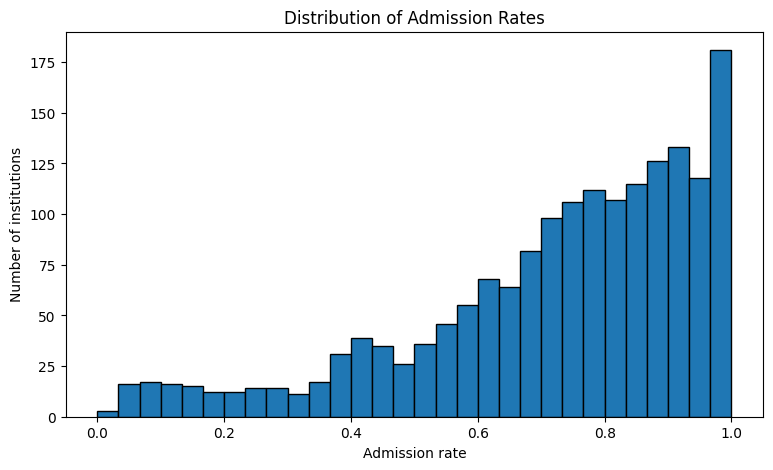

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(df_model[TARGET].dropna(), bins=30, edgecolor="black")
plt.xlabel("Admission rate")
plt.ylabel("Number of institutions")
plt.title("Distribution of Admission Rates")
plt.show()

Interpretation: The admission-rate distribution has a skewness of −1.069, so it is strongly skewed to the left. Most institutions in the dataset have relatively high admission rates, particularly between about 0.70 and 1.00, while a smaller number of highly selective institutions have much lower admission rates. This means that the mean may be pulled downward by institutions with very low admission rates, so the median may be a more representative measure of the typical institution.

The uneven distribution may also make very selective institutions more difficult for the model to predict accurately because there are fewer examples of them in the dataset.

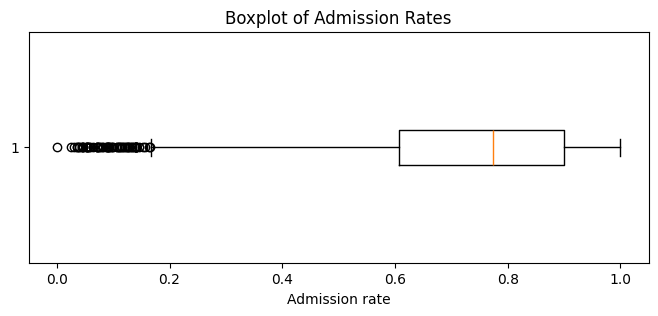

In [9]:
plt.figure(figsize=(8, 3))
plt.boxplot(df_model[TARGET], vert=False)
plt.xlabel("Admission rate")
plt.title("Boxplot of Admission Rates")
plt.show()

Interpretation: The middle 50% of institutions have admission rates between 0.606 and 0.900, and the median admission rate is 0.774. The much longer lower whisker and the cluster of low-value outliers support the conclusion that the distribution is skewed to the left. The potential outliers mainly represent highly selective institutions with unusually low admission rates, so they were retained rather than treated as data errors.

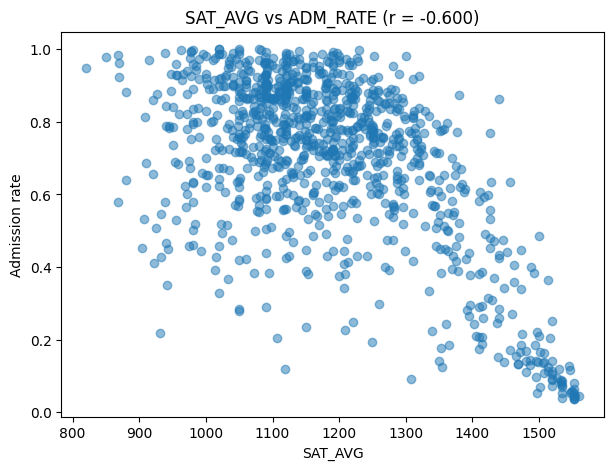

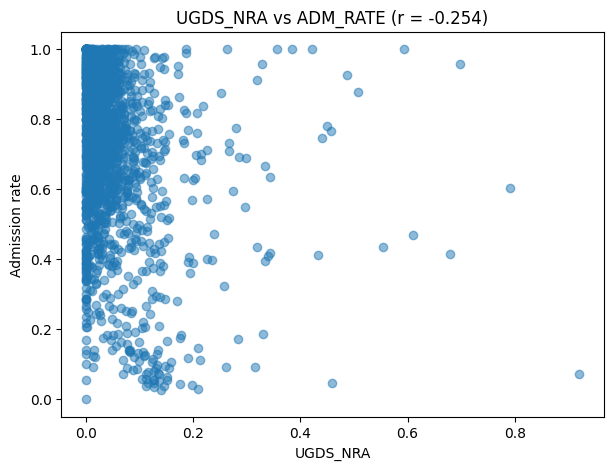

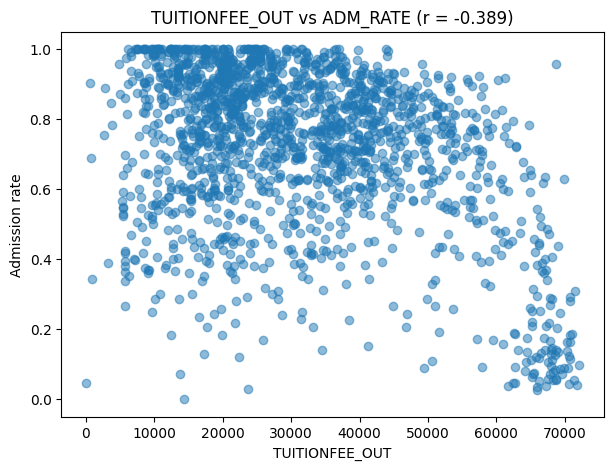

In [10]:
scatter_features = [
    "SAT_AVG",
    "UGDS_NRA",
    "TUITIONFEE_OUT"
]

for feature in scatter_features:
    plot_data = df_model[[feature, TARGET]].dropna()
    correlation = plot_data[feature].corr(plot_data[TARGET])

    plt.figure(figsize=(7, 5))
    plt.scatter(plot_data[feature], plot_data[TARGET], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("Admission rate")
    plt.title(f"{feature} vs ADM_RATE (r = {correlation:.3f})")
    plt.show()

Interpretation: SAT_AVG has the strongest relationship with admission rate, with a correlation of −0.600. Colleges with higher average SAT scores usually have lower admission rates.

TUITIONFEE_OUT has a weaker negative correlation of −0.389, suggesting that institutions with higher out-of-state tuition tend to have lower admission rates, although the points are widely scattered.

UGDS_NRA has the weakest relationship, with a correlation of −0.254. Most institutions have a very small proportion of non-resident-alien undergraduates, and a few unusually high values may affect the trend line, so this relationship should be interpreted cautiously.

                ADM_RATE  SAT_AVG  ACTCMMID  UGDS  UGDS_NRA  TUITIONFEE_OUT  \
ADM_RATE            1.00    -0.60     -0.56 -0.05     -0.25           -0.39   
SAT_AVG            -0.60     1.00      0.93  0.17      0.36            0.74   
ACTCMMID           -0.56     0.93      1.00  0.22      0.29            0.74   
UGDS               -0.05     0.17      0.22  1.00     -0.04            0.02   
UGDS_NRA           -0.25     0.36      0.29 -0.04      1.00            0.24   
TUITIONFEE_OUT     -0.39     0.74      0.74  0.02      0.24            1.00   
COSTT4_A           -0.40     0.67      0.65 -0.15      0.34            0.92   

                COSTT4_A  
ADM_RATE           -0.40  
SAT_AVG             0.67  
ACTCMMID            0.65  
UGDS               -0.15  
UGDS_NRA            0.34  
TUITIONFEE_OUT      0.92  
COSTT4_A            1.00  


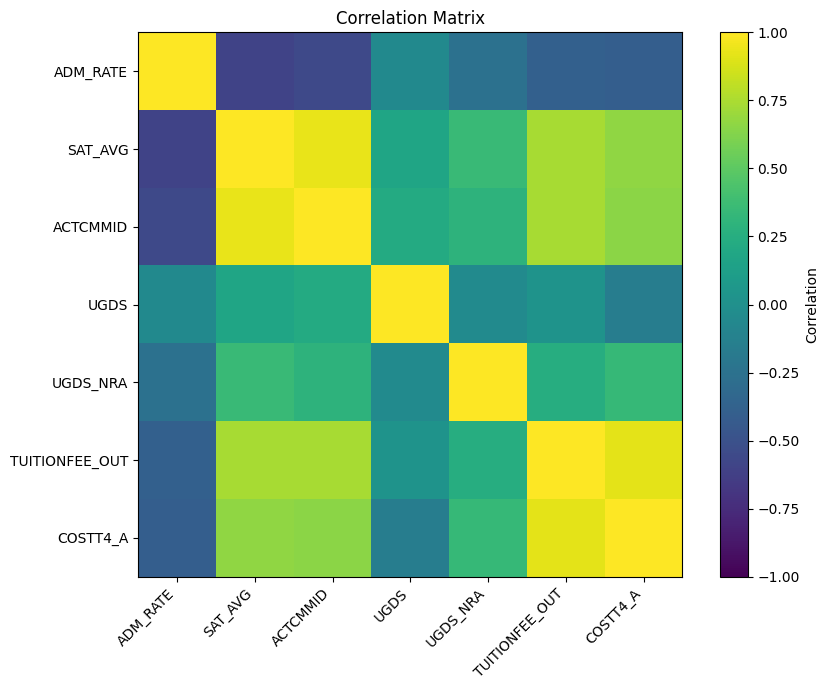

In [11]:
correlation_columns = [TARGET] + numeric_features
correlation_matrix = df_model[correlation_columns].corr()

print(correlation_matrix.round(2))

plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Interpretation: SAT_AVG has the strongest correlation with ADM_RATE at −0.600, followed by ACTCMMID at −0.561 and COSTT4_A at −0.399. This means that institutions with higher SAT scores, ACT scores, and costs generally tend to have lower admission rates. However, correlation does not prove that these variables cause lower admission rates.

The matrix also shows very strong correlations between SAT_AVG and ACTCMMID (0.93) and between TUITIONFEE_OUT and COSTT4_A (0.92). This suggests that these pairs contain similar information and may create multicollinearity in the linear regression model. As a result, the individual regression coefficients may be less reliable, even if the model’s overall prediction performance remains acceptable.

This is an important pre-modelling visualisation because it helps identify which variables are related to the target and which predictors overlap strongly with one another.

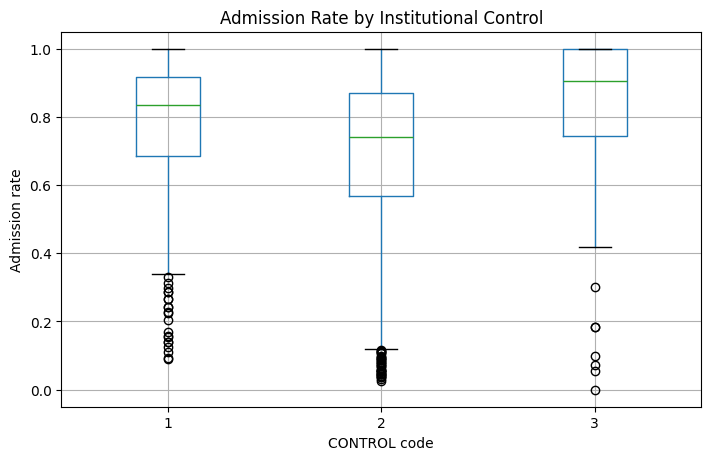

In [12]:
df_model.boxplot(
    column=TARGET,
    by="CONTROL",
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("Admission Rate by Institutional Control")
plt.xlabel("CONTROL code")
plt.ylabel("Admission rate")
plt.show()

Interpretation: The median admission rate differs across the three institutional-control groups. Private for-profit institutions (CONTROL = 3) have the highest median admission rate at 0.907, followed by public institutions (CONTROL = 1) at 0.836. Private nonprofit institutions (CONTROL = 2) have the lowest median admission rate at 0.740. This suggests that institutional control is associated with admission rate, although the graph does not show that institutional control directly causes these differences.

# Q6. Build the machine-learning model

`ADM_RATE` is the target variable. The predictor variables were initially selected based on their relevance to institutional selectivity, their interpretability, and their availability in the College Scorecard dataset. SAT_AVG and ACTCMMID represent the academic profile of admitted students and may be associated with how selective an institution is. UGDS represents institutional size, while UGDS_NRA represents the proportion of international undergraduates. TUITIONFEE_OUT and COSTT4_A describe the financial characteristics of an institution, which may differ between highly selective and less selective institutions. The categorical variables CONTROL, PREDDEG, HIGHDEG, REGION, and LOCALE were included to account for structural and geographical differences between institutions.

In [13]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

# Separate the predictors from the target variable.
X = df_model[numeric_features + categorical_features]
y = df_model[TARGET]

# Use 80% of the data for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train the multiple linear regression model.
baseline_model.fit(X_train, y_train)

# Predict admission rates for the unseen test data.
baseline_predictions = baseline_model.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

baseline_results = pd.DataFrame({
    "RMSE": [baseline_rmse],
    "MAE": [baseline_mae],
    "R2": [baseline_r2]
}, index=["Baseline Linear Regression"])

baseline_results.round(4)

,RMSE,MAE,R2
Baseline Linear Regression,0.1971,0.151,0.3264


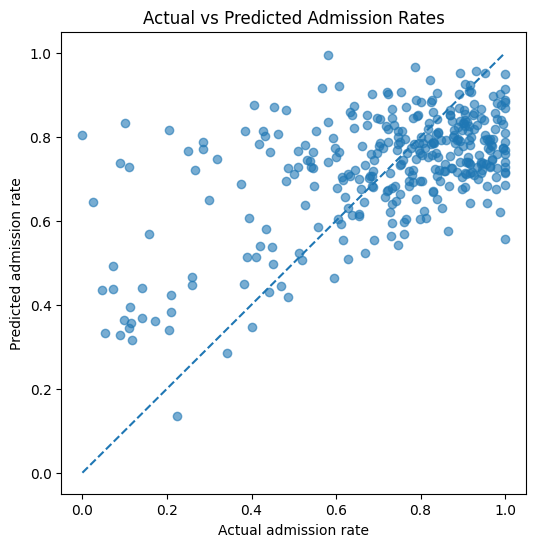

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, baseline_predictions, alpha=0.6)

minimum = min(y_test.min(), baseline_predictions.min())
maximum = max(y_test.max(), baseline_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual admission rate")
plt.ylabel("Predicted admission rate")
plt.title("Actual vs Predicted Admission Rates")
plt.show()

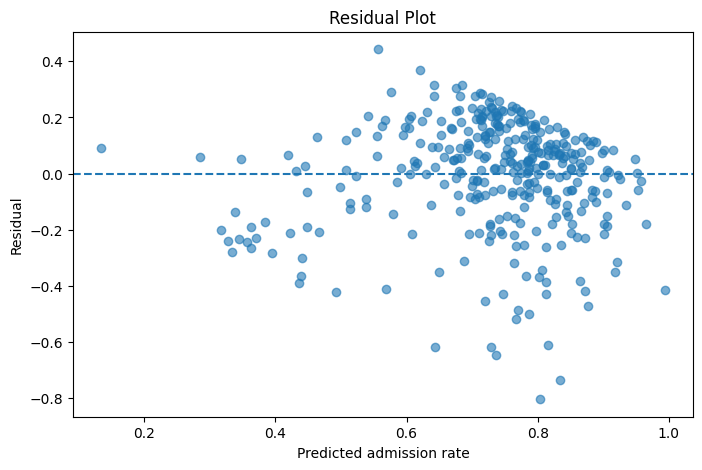

In [15]:
residuals = y_test - baseline_predictions

plt.figure(figsize=(8, 5))
plt.scatter(baseline_predictions, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted admission rate")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

The actual-versus-predicted plot shows that the model tends to predict values closer to the middle of the admission-rate range. It often overpredicts admission rates for highly selective institutions and underpredicts some institutions with very high admission rates. The residuals are centred roughly around zero, but they do not appear completely random and their spread varies across the predicted values. This suggests that the linear model captures part of the relationship but does not fully represent the more complex patterns in the data.

# Q7. Validation using five-fold cross-validation

In [16]:
# Perform five-fold cross-validation to test model stability.
cross_validation = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

rmse_scores = np.sqrt(-cross_val_score(
    baseline_model,
    X,
    y,
    cv=cross_validation,
    scoring="neg_mean_squared_error"
))

mae_scores = -cross_val_score(
    baseline_model,
    X,
    y,
    cv=cross_validation,
    scoring="neg_mean_absolute_error"
)

r2_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=cross_validation,
    scoring="r2"
)

cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "RMSE": rmse_scores,
    "MAE": mae_scores,
    "R2": r2_scores
})

print(cv_results.round(4))
print()
print("Mean RMSE:", round(rmse_scores.mean(), 4))
print("RMSE standard deviation:", round(rmse_scores.std(ddof=1), 4))
print("Mean MAE:", round(mae_scores.mean(), 4))
print("Mean R²:", round(r2_scores.mean(), 4))

   Fold    RMSE     MAE      R2
0     1  0.1971  0.1510  0.3264
1     2  0.1803  0.1422  0.3032
2     3  0.2001  0.1621  0.2829
3     4  0.1981  0.1551  0.2593
4     5  0.1877  0.1494  0.2750

Mean RMSE: 0.1926
RMSE standard deviation: 0.0084
Mean MAE: 0.152
Mean R²: 0.2894


The mean cross-validated RMSE is 0.1926, with a standard deviation of 0.0084. The small standard deviation shows that model performance is relatively stable across the five folds. The mean cross-validated MAE is 0.1520 and the mean R² is 0.2894.

# Q8. Feature engineering

Two manually created features are tested:

- `INTL_STUDENT_COUNT = UGDS × UGDS_NRA`
- `COST_ABOVE_TUITION = COSTT4_A − TUITIONFEE_OUT`

A second model also uses degree-two polynomial features, which include squared terms and pairwise interactions between numerical variables.

In [17]:
engineered_df = df_model.copy()

# Estimate the number of international undergraduates.
engineered_df["INTL_STUDENT_COUNT"] = (
    engineered_df["UGDS"] * engineered_df["UGDS_NRA"]
)

# Estimate costs other than out-of-state tuition.
engineered_df["COST_ABOVE_TUITION"] = (
    engineered_df["COSTT4_A"] - engineered_df["TUITIONFEE_OUT"]
)

engineered_numeric_features = numeric_features + [
    "INTL_STUDENT_COUNT",
    "COST_ABOVE_TUITION"
]

manual_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        engineered_numeric_features
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

X_engineered = engineered_df[
    engineered_numeric_features + categorical_features
]

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

manual_model = Pipeline([
    ("preprocessor", manual_preprocessor),
    ("model", LinearRegression())
])

manual_model.fit(X_train_eng, y_train_eng)
manual_predictions = manual_model.predict(X_test_eng)

manual_rmse = np.sqrt(mean_squared_error(y_test_eng, manual_predictions))
manual_mae = mean_absolute_error(y_test_eng, manual_predictions)
manual_r2 = r2_score(y_test_eng, manual_predictions)

In [18]:
polynomial_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

polynomial_preprocessor = ColumnTransformer([
    ("numeric", polynomial_numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

polynomial_model = Pipeline([
    ("preprocessor", polynomial_preprocessor),
    ("model", LinearRegression())
])

polynomial_model.fit(X_train, y_train)
polynomial_predictions = polynomial_model.predict(X_test)

polynomial_rmse = np.sqrt(
    mean_squared_error(y_test, polynomial_predictions)
)
polynomial_mae = mean_absolute_error(
    y_test,
    polynomial_predictions
)
polynomial_r2 = r2_score(
    y_test,
    polynomial_predictions
)

feature_engineering_results = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Linear Regression + Manual Features",
        "Polynomial Regression"
    ],
    "RMSE": [
        baseline_rmse,
        manual_rmse,
        polynomial_rmse
    ],
    "MAE": [
        baseline_mae,
        manual_mae,
        polynomial_mae
    ],
    "R2": [
        baseline_r2,
        manual_r2,
        polynomial_r2
    ]
})

feature_engineering_results.sort_values("RMSE").round(4)

,Model,RMSE,MAE,R2
2,Polynomial Regression,0.1898,0.1428,0.3754
1,Linear Regression + Manual Features,0.1922,0.1477,0.3593
0,Baseline Linear Regression,0.1971,0.1510,0.3264


The polynomial regression model performed best among the feature-engineering models. Its RMSE was 0.1898 and its R² was 0.3754. The manually engineered model also improved on the baseline, but the polynomial model produced the larger improvement.

# Additional work: Random Forest and SVR

In [19]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    ))
])

random_forest_model.fit(X_train, y_train)
rf_predictions = random_forest_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)


svr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.05
    ))
])

svr_model.fit(X_train, y_train)
svr_predictions = svr_model.predict(X_test)

svr_rmse = np.sqrt(mean_squared_error(y_test, svr_predictions))
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_r2 = r2_score(y_test, svr_predictions)


all_model_results = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Linear Regression + Manual Features",
        "Polynomial Regression",
        "Random Forest Regressor",
        "Support Vector Regression"
    ],
    "RMSE": [
        baseline_rmse,
        manual_rmse,
        polynomial_rmse,
        rf_rmse,
        svr_rmse
    ],
    "MAE": [
        baseline_mae,
        manual_mae,
        polynomial_mae,
        rf_mae,
        svr_mae
    ],
    "R2": [
        baseline_r2,
        manual_r2,
        polynomial_r2,
        rf_r2,
        svr_r2
    ]
})

all_model_results.sort_values("RMSE").round(4)

,Model,RMSE,MAE,R2
3,Random Forest Regressor,0.1807,0.1331,0.4337
2,Polynomial Regression,0.1898,0.1428,0.3754
1,Linear Regression + Manual Features,0.1922,0.1477,0.3593
0,Baseline Linear Regression,0.1971,0.1510,0.3264
4,Support Vector Regression,0.2214,0.1698,0.1501


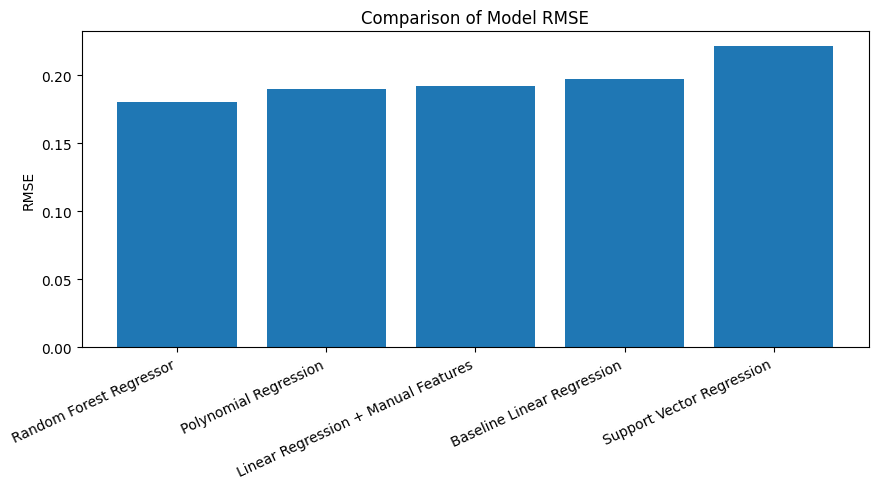

In [20]:
sorted_results = all_model_results.sort_values("RMSE")

plt.figure(figsize=(9, 5))
plt.bar(sorted_results["Model"], sorted_results["RMSE"])
plt.ylabel("RMSE")
plt.title("Comparison of Model RMSE")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Random Forest produced the best overall result, with an RMSE of 0.1807, an MAE of 0.1331, and an R² of 0.4337. Polynomial regression was the best linear model. Support Vector Regression performed worse than the baseline model.

# Q9. Programming style

The code uses meaningful variable names, comments, indentations, and a fixed random state. The main stages are separated into sections so that the workflow can be followed from data loading to final evaluation.

# Q10. Evaluation of the project and its results

The project implemented a regression model for estimating the reported admission rates of four-year U.S. institutions. The principal linear regression model achieved a test RMSE of 0.1971, an MAE of 0.1510, and an R² of 0.3264.

RMSE was selected as the main evaluation measure because it gives greater weight to large prediction errors. MAE was also reported because it can be interpreted directly in admission-rate units, while R² shows the proportion of variation explained by the model.

Five-fold cross-validation produced a mean RMSE of 0.1926 with a standard deviation of 0.0084. This indicates that the model’s performance was relatively stable across different data splits because the RMSE values varied only slightly between folds. Polynomial Regression was the best-performing linear model. However, Random Forest performed best overall, achieving an RMSE of 0.1807, an MAE of 0.1331, and an R² of 0.4337. This suggests that some relationships between the predictors and admission rate are nonlinear.

The project contributes to admissions consulting by demonstrating how public institutional data can support the analysis of university selectivity. However, the model does not include applicant-level factors such as grades, essays, recommendations, intended major, citizenship, or institutional priorities. Therefore, the results should not be interpreted as an individual student's probability of admission. The workflow could be transferred to other education-related regression problems, provided that the target variable is continuous and the new dataset is appropriately cleaned and evaluated.

# Limitations

- The model studies relationships and performance; it does not replace official reported rates.
- Test-score reporting and admissions policies differ across institutions.
- Categorical codes must be checked against the correct College Scorecard data dictionary.
- The model does not establish causation.
- The model should support exploration, not automate high-stakes admissions decisions.

# References

Lee, H., Kizilcec, R. F., & Joachims, T. (2023). Evaluating a learned admission-prediction model as a replacement for standardized tests in college admissions. In *Proceedings of the Tenth ACM Conference on Learning @ Scale*. https://doi.org/10.1145/3573051.3593382

U.S. Department of Education. (n.d.). *College Scorecard data*. https://collegescorecard.ed.gov/data/

Scikit-learn developers. (n.d.). *Cross-validation: Evaluating estimator performance*. https://scikit-learn.org/stable/modules/cross_validation.html